In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from sklearn.metrics import accuracy_score

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

delhi = pd.read_csv('Delhi_Dataset.csv')
dhaka = pd.read_csv('Dhaka_Dataset.csv')
df = pd.concat([delhi, dhaka], ignore_index=True)

#DAtaset : https://drive.google.com/drive/folders/1rKonLoT0vYsMopx3nkskdiYjm7I6vf84
# df = pd.read_csv('combined.csv')

In [ ]:
# Labgena :
#  30  description       3654 non-null   object
#  31  icon              3654 non-null   object
#  32  stations          3654 non-null   object

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df = df.drop(['datetime', 'description', 'icon', 'stations', 'severerisk',
                   'sunrise', 'sunset', 'moonphase', 'snow', 'snowdepth',
                   'solarradiation', 'solarenergy'], axis=1)

df['preciptype'].fillna("no rain", inplace=True)
df['precip'] = pd.to_numeric(df['precip'], errors='coerce')
df['precip'] = df['precip'].fillna(0)

df['name'] = df['name'].str.lower()
df['name'] = le.fit_transform(df['name'])


In [ ]:
df['preciptype'] = le.fit_transform(df['preciptype'])
df['conditions'] = le.fit_transform(df['conditions'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              3654 non-null   int64  
 1   tempmax           3654 non-null   float64
 2   tempmin           3654 non-null   float64
 3   temp              3654 non-null   float64
 4   feelslikemax      3654 non-null   float64
 5   feelslikemin      3654 non-null   float64
 6   feelslike         3654 non-null   float64
 7   dew               3654 non-null   float64
 8   humidity          3654 non-null   float64
 9   precip            3654 non-null   float64
 10  precipprob        3654 non-null   int64  
 11  precipcover       3654 non-null   float64
 12  preciptype        3654 non-null   int64  
 13  windgust          3654 non-null   float64
 14  windspeed         3654 non-null   float64
 15  winddir           3654 non-null   float64
 16  sealevelpressure  3654 non-null   float64


In [ ]:
## hard soft  svm ;;
## C er value change -- > Grid Search ;;
##
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [ ]:
x = df.drop('name', axis=1)
y = df['name']

from sklearn.preprocessing import StandardScaler, RobustScaler

col_o = [ 'uvindex' ,'visibility','windspeed','windgust','precipcover','precip',]
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()
col = [col for col in df if col not in col_o]
df[col] = standard_scaler.fit_transform(df[col])
df[col_o] = robust_scaler.fit_transform(df[col_o])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
model = LogisticRegression(max_iter=1000)
rfe = RFE(model, n_features_to_select=15)
fit = rfe.fit(x_train, y_train)
selected_features = x_train.columns[fit.support_]

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
x_train_selected = x_train[selected_features]
x_test_selected = x_test[selected_features]

In [ ]:
# C_val = [0.01, 0.1, 0.5, 1, 1.5, 2, 10, 100, 200, 500, 1000, 10000, 1000000]
param_grid = {'C': [0.01, 0.1, 0.5, 1, 1.5, 2, 10],  'kernel': ['linear']}
# param_grid = dict(C = C_val);

grid = GridSearchCV(SVC(), param_grid, cv = 10, scoring = 'accuracy')
grid.fit(x_train_selected, y_train)

best_model = grid.best_estimator_
print(f'Best cross-validation accuracy: {grid.best_score_}')
print(f'Best hyperparameters: {grid.best_params_}')

Best cross-validation accuracy: 0.9358639705882353
Best hyperparameters: {'C': 0.1, 'kernel': 'linear'}


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = best_model.predict(x_test_selected)


f1_ans = f1_score(y_test, y_pred, average='weighted')
precision_ans = precision_score(y_test, y_pred, average='weighted')
recall_ans = recall_score(y_test, y_pred, average='weighted')

print("\n\nF1 : ", f1_ans)
print("Precision : ", precision_ans)
print("Recall : ", recall_ans)

training_accuracy = best_model.score(x_train_selected, y_train)
test_accuracy = best_model.score(x_test_selected, y_test)
print("Training Accuracy:", training_accuracy)
print("Test Accuracy:", test_accuracy)



F1 :  0.9262216187212188
Precision :  0.9270953358536168
Recall :  0.92616226071103
Training Accuracy: 0.9378177551818537
Test Accuracy: 0.92616226071103


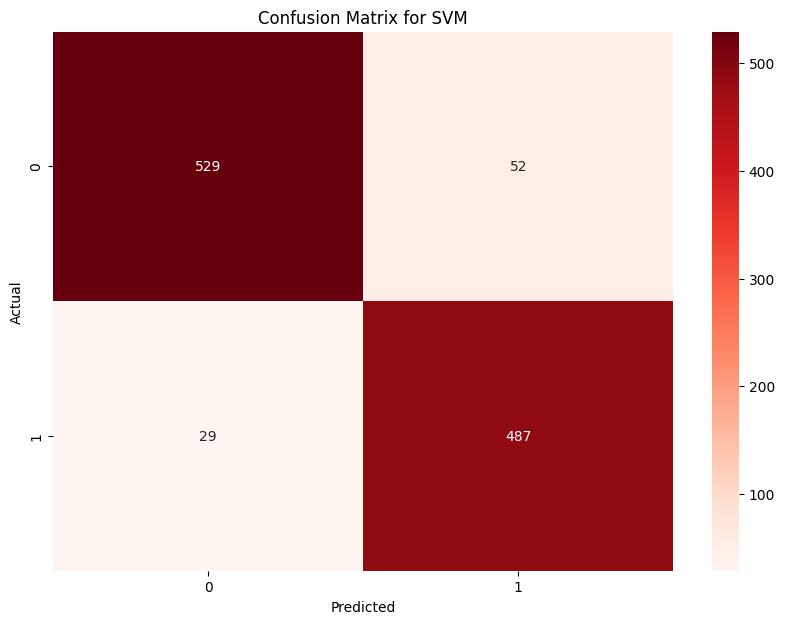

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Reds")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM')
plt.show()

In [ ]:
selected_features

Index(['tempmax', 'tempmin', 'temp', 'feelslikemin', 'feelslike', 'dew',
       'humidity', 'precip', 'precipcover', 'preciptype', 'windgust',
       'windspeed', 'sealevelpressure', 'visibility', 'uvindex'],
      dtype='object')

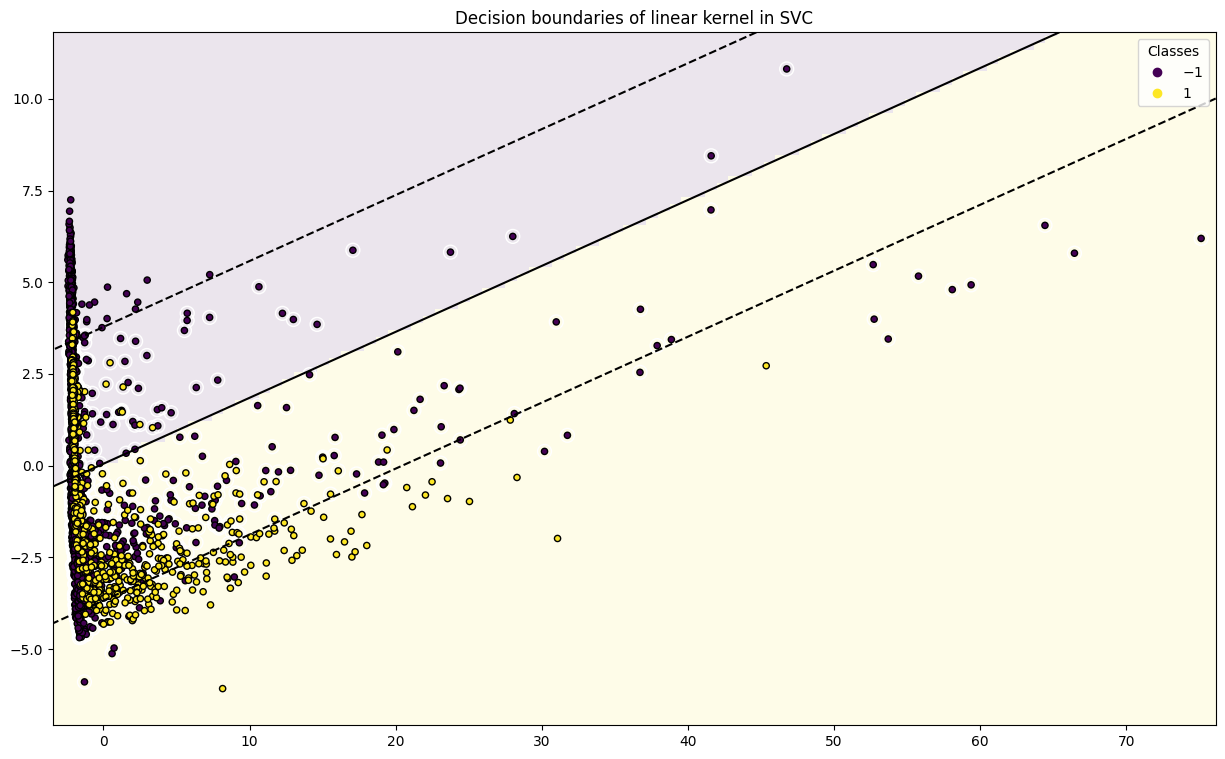

In [ ]:
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

def plot_training_data_with_decision_boundary(X, y, kernel='linear', ax=None, long_title=True, support_vectors=True, row_start=0, row_end=None):

    if row_end is None:
        row_end = len(X)
    X_subset = X[row_start:row_end]
    y_subset = y[row_start:row_end]


    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_subset)

    clf = svm.SVC(kernel=kernel, gamma=2, class_weight='balanced').fit(X_pca, y_subset)


    if ax is None:
        _, ax = plt.subplots(figsize=(15, 9))
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max))

    param_grid_pcolormesh = {
        "estimator": clf,
        "X": X_pca,
        "ax": ax,
        "response_method": "predict",
        "plot_method": "pcolormesh",
        "alpha": 0.1,
    }


    DecisionBoundaryDisplay.from_estimator(**param_grid_pcolormesh)

    param_grid_contour = {
        "estimator": clf,
        "X": X_pca,
        "ax": ax,
        "response_method": "decision_function",
        "plot_method": "contour",
        "levels": [-1, 0, 1],
        "colors": ["k", "k", "k"],
        "linestyles": ["--", "-", "--"],
    }

    DecisionBoundaryDisplay.from_estimator(**param_grid_contour)

    if support_vectors:

        ax.scatter(
            clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            s=100,
            facecolors="none",
            edgecolors="white",
        )


    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_subset, s=20, edgecolors="k")
    ax.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
    if long_title:
        ax.set_title(f"Decision boundaries of {kernel} kernel in SVC")
    else:
        ax.set_title(kernel)

    if ax is None:
        plt.show()

X = df[selected_features].values
y = df['name'].values


row_start = 100
row_end = 2500


plot_training_data_with_decision_boundary(X, y, kernel='linear', row_start=row_start, row_end=row_end)
